# XX. Summary of germination models

## Week 13/2026

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

This notebook provides a systematic summary of all diffusion-driven germination models in the study. Furthermore, a reparameterisation framework is presented for their simplification.

## 1. Geometric variables

A spore is idealised as a sphere with a radius $r_s$, a surface area $A_s=4\pi r_s^2$ and a volume $V_s=4/3 \pi r_s^3$. The cell wall can be viewed as the outermost shell of this sphere, consisting of two thinner shells: an outer, hydrophobin-rich layer with a thickness $h_\textrm{hp}$ and an inner, polysaccharide-rich layer with a thickness $h_{\textrm{ps}}$.

The volume of the inner cell wall is considered the main compartment of inducer saturation. The total volume can be calculated as

$$
V_{\textrm{ps}}=\frac{4}{3}\pi\left[(r_s-d_{\textrm{hp}})^3-(r_s-d_{\textrm{hp}}-d_{\textrm{ps}})^3\right],
$$

which reflects the subtraction of the protoplast (membrane included) from the internal volume without the outer cell wall. Since the thickness of the hydrophobin layer is determined by the size of the hydrophobin rodlets, it can be considered nearly constant. On the other hand, the spore radius and the inner cell wall may exhibit much larger variations. For this reason, the spore radius $r_s$ can be modelled by a normally distributed random variable $R$ with a mean $\mu_R$ and a standard deviation $\sigma_R$. Similarly, the inner cell wall thickness can be modelled by a random variable $H$ with a mean $\mu_H$ and a standard deviation $\sigma_H$. It is important to consider that the inducer can occupy at most only the vacant fraction of the total volume, which according to studies[1] is approximately 24%. Thus, the expression for the effective inner cell wall volume becomes

$$
V_{\textrm{ps, eff}}=0.24\frac{4}{3}\pi\left[(R-d_{\textrm{hp}})^3-(R-d_{\textrm{hp}}-H)^3\right].
$$

Similarly, the other geometric variables can incorporate the random spore radius:

$$
A_s=4\pi R^2,
$$

$$
V_s=4/3 \pi R^3.
$$

Assuming that spores at an inoculum density of $\rho_s$ are positioned in a regular grid, a designated volume per spore can be defined as

$$
\begin{equation}
V_{\textrm{des}}=\frac{1}{\rho_s}.
\end{equation}
$$

Even if molecules diffuse over its boundaries into adjacent volumes, this occurs in a symmetric fashion, so that the net quantity of molecules within a volume remains preserved. Consecutively, one can separate this volume into the space occupied by the spore, $V_s$, and that remaining for the medium, $V_{\textrm{free}}=V_{\textrm{des}}-V_s$. A volume fraction, denoting the percentage per unit volume occupied by the conidia, can be defined as $\phi=\rho_s V_s$.

## 2. Main molecular components

Germination is considered to be primarily dependent on two molecular actors - an inhibitor $\textrm{I}$ (e.g. 1-octen-3-ol) and an inducer $\textrm{C}$ (e.g. alanine). There are 4 relevant types of concentration:
- $c_{\textrm{in}}^{\textrm{I}}$ - concentration of inhibitor in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{I}}$ - concentration of inhibitor in the extracellular medium;
- $c_{\textrm{in}}^{\textrm{C}}$ - concentration of inducer in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{C}}$ - concentration of inducer in the extracellular medium.

At inoculation, the interior concentration of inhibitor is defined as

$$
c_{\textrm{in}}^{\textrm{I}}(t=0)=c_0.
$$

Furthermore, any exterior concentration of inhibitor present at inoculation is defined as

$$
c_{\textrm{out}}^{\textrm{I}}(t=0)=c_{\textrm{ex}}^{\textrm{I}}.
$$

In most cases in this study, $c_{\textrm{ex}}^{\textrm{I}}=0$.

The inhibitor molecules strive to equilibrate across the cell wall. Taking into account the density of spores as sources of inhibitor dispersal, the internal inhibitor concentration at any spore over time can be calculated as

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}}\right] c_0+(1-\phi)\left(1-e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right)c_{\textrm{ex}}^{\textrm{I}}
$$

or simply

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right] c_0
$$

if $c_{\textrm{ex}}^{\textrm{I}}=0$. The two important variables here are the volume fraction $\phi$ and

$$
\tau^{\textrm{I}}=\frac{V_s}{P_{\textrm{eff}}^{\textrm{I}}A_s},
$$

which is a characteristic permeation time related to the volume to surface area ratio of the spore and the effective permeation constant $P_{\textrm{eff}}^{\textrm{I}}$ of the inhibitor, valid for the entire cell wall complex. 

A picture of the induction mechanism may be more accurately painted using the available knowledge about carbon-sensitive receptor proteins tethered to the cell membrane. This supports the representation of the inner cell wall as an inducer-soaking compartment, with the outer cell wall being a diffusion-limiting barrier. In the inhibitor case, however, the situation is different. Since there is insufficient evidence for the exact locations where the inhibitor originates and exerts its effect, it is harder to generalise which volumes are relevant for its concentration equilibration and which cell wall layers should be considered in the permeation between spore and medium. Therefore, the full spore volume and area ($V_s$ and $A_s$) are taken as approximate reference and $P_{\textrm{eff}}^{\textrm{I}}$ may account for any number of diffusion-limiting barriers: the cell membrane, the inner cell wall, the hydrophobin layer. In any combination of $M$ of these layers, the permeability is computed through the expression

$$
\frac{1}{P_{\textrm{eff}}^{\textrm{I}}}=\sum_i^M{\frac{1}{P_i^{\textrm{I}}}}.
$$

Contrary to this, the equilibration of inducer concentration over the hydrophobin barrier only takes into account a permeation constant $P_{\textrm{eff}}^{\textrm{C}}$ of the inducer molecule through the rodlet layer and obeys the formula

$$
c_{\textrm{in}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}(1-e^{-t/\tau^{\textrm{C}}}),
$$

where $c_{\textrm{ex}}^{\textrm{C}}$ is the initial external inducer concentration (considered effectively constant) and

$$
\begin{equation}
\tau^{\textrm{C}}=\frac{V_{\textrm{ps, eff}}}{P_s^{\textrm{C}}A_s},
\end{equation}
$$

i.e. the characteristic permeation time is dependent on the inner cell wall compartment and not on the entire spore volume.

## 3. Germination mechanisms

Under the general assumption that both the release of inhibition and a strong enough inducing signal must be present for germination, the break of dormancy can be expressed as an instantaneous event that depends on a twofold criterion:

$$
c_{\textrm{in}}^{\textrm{I}}(t) < \gamma c_0^{\textrm{I}} \quad \textrm{and} \quad s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right) > \omega.
$$

The first criterion states that germination becomes possible when the internal inhibitor concentration is below a certain fraction $\gamma$ (with $0<\gamma<1$) of its initial concentration. By specifying

$$
c_{\textrm{in}}^{\textrm{I}}(t) = \beta c_0,
$$

where

$$
\beta=\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}},
$$

one can simplify the criterion as

$$
\beta < \gamma.
$$

It is natural to assume that the threshold value $\beta$ is not universal for all spores but rather depends on a complex network of factors, which can be reflected by modelling it as a Normal random variable $X$, with mean $\mu_X$ and standard deviation $\sigma_X$.

The second criterion enables germination when an inducing signal produced by the inducer concentration inside the outer cell wall becomes larger than a certain threshold $\omega$ (with $0<\omega<1$) of the outside concentration (which for simplicity is considered constant). Due to the known mechanisms of ligation to receptor molecules, the inducing effect is not linear with the concentration but can be assumed to follow Michaelis-Menten dynamics:

$$
s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right)=s_{\textrm{max}} \frac{c_{\textrm{in}}^\textrm{C}(t)}{K_s^\textrm{C}+c_{\textrm{in}}^\textrm{C}(t)}
$$

with a saturation level $s_{\textrm{max}}$ (set to $1$ to normalize the signal against the threshold) and a half-saturation constant $K_s^\textrm{C}$.

Such an assumption could not be made for the inhibitor due to lack of evidence, hence its simpler formulation. On the other hand, the inducer condition does not allow analogical cancellations (e.g. of $c_{\textrm{ex}}^{\textrm{C}}$), so we keep the full inequality expression.

Once again, the threshold $\omega$ may be influenced by many factors, so it is best modelled by a Normal random variable $Y$ with mean $\mu_Y$ and standard deviation $\sigma_Y$.

In the simplest case, when the inhibitor and inducer are non-interacting, the probability of a spore germinating at a given time can be expressed as

$$
p(t) = \mathbb{P}{(\beta < X \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_X{(\beta)}\right]\, f_R(r_s) \, F_Y{(s)} \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}},
$$

where

$$
F_X{(\beta)}=\Phi{\left(\frac{\beta(r_s, t)-\mu_X}{\sigma_X}\right)}
$$

and

$$
F_Y{(s)}=\Phi{\left(\frac{s(K_s^\textrm{C}, r_s, d_{\textrm{ps}}, t)-\mu_Y}{\sigma_Y}\right)}
$$

are cumulative distribution functions,

$$
f_R(r_s) = \frac{1}{\sqrt{2\pi}\sigma_R}\exp{\left(-\frac{(r_s-\mu_R)}{2\sigma_R^2}\right)}
$$

and

$$
f_H(d_{\textrm{ps}}) = \frac{1}{\sqrt{2\pi}\sigma_H}\exp{\left(-\frac{(d_{\textrm{ps}}-\mu_H)}{2\sigma_H^2}\right)}
$$

are Normal probability density functions, and a separate integral is taken over all possible values for the two random variables $R$ and $H$.

A constrain is imposed on all random variable parameters that their standard deviation must not exceed the order of the mean, otherwise they would produce unrealistically wide distributions. Therefore, instead of manipulating the $\sigma$ parameters directly, an exponent parameter $\delta$ is assigned to each random variable distribution, such that

$$
\sigma=\mu e^{-\delta}.
$$

In summary, the free parameters of this model are $P_{\textrm{eff}}^{\textrm{I}}$, $P_s^{\textrm{C}}$, $K_s^\textrm{C}$, $\mu_X$, $\delta_X$, $\mu_Y$ and $\delta_Y$.

## 4. Interactions

The probability expression becomes more complex once interactions between the inhibitor and the inducer come into play. Starting from the basic model, several primary nodes are pinpointed that may interact with each other:

- the inducing signal strength $s$;
- the induction threshold $\omega$;
- the inhibition threshold $\gamma$;
- the cell wall permeability for inducer and inhibitor molecules.

This enables outlining the following interactions of interest, labelled by capital letters:

- ($\textrm{A}$) the inducer causes an increased cell wall permeability (aligned with dormancy-breaking processes in spores), making it easier for inducing molecules to reach the membrane-bound receptors and for inducer molecules to deplete.
- ($\textrm{B}$) the inducer increases the inhibition threshold by promoting (via mass-action dynamics) an effect that makes the spore less succeptible to inhibition;
- ($\textrm{C}$) the inhibitor reduces the maximum possible signal strength, either by directly blocking the binding sites or by some other mass-action effect further down the signalling pathway (inhibitor dynamics expression multiplied with the signal strength);
- ($\textrm{D}$) the inhibitor causes a reduced cell wall permeability (aligned with observations of dormant spores), making it more difficult for inducing molecules to reach the membrane-bound receptors and for inducer molecules to deplete;
- ($\textrm{E}$) the inhibitor increases the induction threshold by promoting (via mass-action dynamics) an effect that makes it more difficult for the inducing signal to trigger germination (standard Michaelis-Menten effect added to threshold);

For the sake of completeness, all possible combinations of these effects are considered, despite the concern that multifacetted effect of the same actor on several nodes may be less biologically plausible. Furthermore, in a scenario where one actor affects the pathway of the other, the former may or may not also contribute to germination directy (e.g. an inhibitor may affect the induction threshold but also co-trigger germination by depleting under its threshold). It is up to the sensitivity analysis to determine whether the prediction power of the model in such cases is overshadowed by its increased complexity.

### 4.1. Inducer modulates permeability (A)

In this scenario, it is considered that the inducing signal arising from the concentration of the carbon source yields a transformation of the permeation constant for both the inducer and the inhibitor molecules. In its simplest formulation, this can happen as a linear offset from a base permeability for small inducer concentrations and reach a saturating permeability for high-inducer concentration $P_{\textrm{max}}$ (here heuristically set to $10^{3}\ \mu\textrm{m/s}$).

For the inducer and the inhibitor permeability, respectively:

$$
P_{\textrm{perturbed}}^{\textrm{C}}=P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{C}}-P_{\textrm{base}}^{\textrm{C}})e^{-\lambda^{\textrm{C}}s},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{I}}-P_{\textrm{base}}^{\textrm{I}})e^{-\lambda^{\textrm{C}}s},
$$

where $\lambda^{\textrm{C}}$ controls the rate at which the permeability shifts based on the concentration-based inducing signal. If the signal additionally triggers germination by surpassing the threshold $\omega$, the half-saturation constant $K_s^\textrm{C}$ implicit in the term is the same as for the permeability-decreasing effect.

The dynamic modulation of the permeability creates a system of ODEs that does not have a closed-form solution and cannot be computed as an integral, like in the previous case. Instead, a numerical Monte Carlo integration of the differential equations is necessary to account for all possible values of the random variable distributions $R$ and $H$.

First, the simpler case is observed where the **inducer only affects the cell wall permeability** and does not directly trigger germination through a threshold-based criterion. The change of inhibitor concentration in the spore over time is given by the ODE

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{I}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{I}}A_s}{V_s}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

The outside concentration changes as

$$
\begin{equation}
\frac{d{c_{\textrm{out}}^{\textrm{I}}}}{d{t}}=\left(\frac{P_{\textrm{perturbed}}^{\textrm{I}}A_s}{V_{\textrm{free}}}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right].
\end{equation}
$$

The concentration drop of inducer across the outer cell wall, on the other hand, follows the formula

$$
\begin{equation}
\frac{d{\Delta c^{\textrm{C}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{C}}A_s}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}\right],
\end{equation}
$$

Since $\Delta c^{\textrm{C}}=c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}$ and $c_{\textrm{out}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}$ is a constant, this equates to

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{C}}A_s}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

Thus, the system of coupled ODEs $\dot{c}_{\textrm{in}}^{\textrm{I}}=\frac{d{\Delta c^{\textrm{I}}}}{d{t}}$, $\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{d{\Delta c^{\textrm{C}}}}{d{t}}$ and $\dot{c}_{\textrm{in}}^{\textrm{C}}=\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}$ needs to be solved. The initial conditions for these ODEs are $c_{\textrm{in}}^{\textrm{I}}{(0)}=c_0$, $c_{\textrm{out}}^{\textrm{I}}{(0)}=0$ and $c_{\textrm{in}}^{\textrm{C}}{(0)}=0$. The initial inhibitor concentration inside the spore ($c_0$) is certainly not uniform over all spores and is therefore modelled by another random variable, $O$, normally distributed with mean $\mu_O$ and standard deviation $\sigma_O$. The Monte Carlo integration must therefore also sample this distribution for the possible germination outcomes.

In [4]:
using CUDA, DiffEqGPU, DifferentialEquations, StaticArrays, Distributions

# ══════════════════════════════════════════════════════════════════════════════
# 1. GPU-compatible types — must be isbits for kernel compatibility
# ══════════════════════════════════════════════════════════════════════════════

struct PermParamsGPU
    A     :: Float32
    Vₛ    :: Float32
    V_out :: Float32
    V_ps  :: Float32
    Pₛ_I  :: Float32
    Pₛ_C  :: Float32
    K_cC  :: Float32    # K_fs[2]
    s     :: Float32    # f_maxs[1]
    c₀_cs :: Float32
end

# ══════════════════════════════════════════════════════════════════════════════
# 2. Out-of-place ODE (EnsembleGPUKernel requires this form)
#    Returns SVector instead of mutating du
# ══════════════════════════════════════════════════════════════════════════════

function ode_inducer_dependent_perm_gpu(u, p::PermParamsGPU, t)
    cinI, cinC, coutI = u[1], u[2], u[3]
    Δg       = p.s * cinC / (p.K_cC + cinC)
    exponent = -(1f0 + Δg) * 1f-3
    PmaxA    = 1000f0 * p.A
    rateI    = PmaxA * (1f0 - exp(exponent * p.Pₛ_I))
    rateC    = PmaxA * (1f0 - exp(exponent * p.Pₛ_C))
    return SVector(
        -(rateI / p.Vₛ)    * (cinI - coutI),
        -(rateC / p.V_ps)  * (cinC - p.c₀_cs),
         (rateI / p.V_out) * (cinI - coutI)
    )
end

# ══════════════════════════════════════════════════════════════════════════════
# 3. CUDA kernels
# ══════════════════════════════════════════════════════════════════════════════

"""
Fused extraction + threshold criterion.
sol_buf layout: (n_states, n_times, n_samp)  — from the H→D pack step
germ_mask layout: (n_samp, n_times)
Each thread handles one (sample, time) pair.
"""
function threshold_kernel(sol_buf, thresh_d, germ_mask_d,
                          n_samp::Int32, n_times::Int32)
    tid = Int32((blockIdx().x - 1) * blockDim().x + threadIdx().x)
    if tid <= n_samp * n_times
        i  = (tid - Int32(1)) % n_samp + Int32(1)   # 1-based sample
        ti = (tid - Int32(1)) ÷ n_samp + Int32(1)   # 1-based time
        # Fuse clamp + criterion — no intermediate c_in_all array needed
        cinI = max(sol_buf[1, ti, i], 0f0)
        germ_mask_d[i, ti] = cinI < thresh_d[i]
    end
    return
end

"""
Enforce monotonicity: once a sample germinates it stays germinated.
One thread per sample; serial over time dimension (typically small).
Runs in-place on germ_mask_d.
"""
function monotonicity_kernel(germ_mask_d, n_samp::Int32, n_times::Int32)
    i = Int32((blockIdx().x - 1) * blockDim().x + threadIdx().x)
    if i <= n_samp
        germinated = false
        @inbounds for ti in Int32(1):n_times
            germinated = germinated | germ_mask_d[i, ti]
            germ_mask_d[i, ti] = germinated
        end
    end
    return
end

# ══════════════════════════════════════════════════════════════════════════════
# 4. Orchestration
# ══════════════════════════════════════════════════════════════════════════════

function gresp_feedback_cuda(sobol_pts, times, geom_samples,
                              c₀_cs, f_maxs, Pₛ_I, Pₛ_C, K_fs,
                              μ_ψ, σ_ψ, μs_thresh, σs_thresh;
                              ks=nothing, n=nothing)

    samples_A, samples_Vₛ, samples_V_out, samples_V_ps = geom_samples
    n_samp  = size(sobol_pts, 2)
    n_times = length(times)

    # ── Sample ψ and inhibitor threshold (CPU, unchanged logic) ──────────────
    μ_ψ_log   = log(μ_ψ^2 / sqrt(σ_ψ^2 + μ_ψ^2))
    σ_ψ_log   = sqrt(log(σ_ψ^2 / μ_ψ^2 + 1))
    samples_ψ = clamp_inplace!(quantile(LogNormal(μ_ψ_log, σ_ψ_log), sobol_pts[3, :]))

    # thresh_criterion_inhibitor only uses threshold row 1
    thresh_cpu = Float32.(quantile(Normal(μs_thresh[1], σs_thresh[1]), sobol_pts[4, :]))
    thresh_d   = CuArray(thresh_cpu)    # length n_samp — single H→D transfer

    # ── Build per-trajectory params and ICs ──────────────────────────────────
    params_cpu = [PermParamsGPU(
        Float32(samples_A[i]),     Float32(samples_Vₛ[i]),
        Float32(samples_V_out[i]), Float32(samples_V_ps[i]),
        Float32(Pₛ_I),             Float32(Pₛ_C),
        Float32(K_fs[2]),          Float32(f_maxs[1]),
        Float32(c₀_cs)
    ) for i in 1:n_samp]

    u0s = [SVector{3, Float32}(Float32(samples_ψ[i]), 0f0, 0f0) for i in 1:n_samp]

    # ── Stage 1: GPU ODE ensemble ─────────────────────────────────────────────
    times_f = Float32.(times)
    tspan   = (0f0, times_f[end])

    prob0 = ODEProblem{false}(ode_inducer_dependent_perm_gpu,
                               u0s[1], tspan, params_cpu[1])
    prob_func(prob, i, repeat) = remake(prob; u0=u0s[i], p=params_cpu[i])

    ep   = EnsembleProblem(prob0; prob_func=prob_func, safetycopy=false)
    sols = solve(ep, EnsembleGPUKernel(GPURosenbrock23()),
                 trajectories=n_samp, saveat=times_f,
                 abstol=1f-6, reltol=1f-6, maxiters=Int(1e8))

    # ── Pack solutions into (3 × n_times × n_samp), then single H→D transfer ─
    # Parallelise the CPU-side extraction across samples with @threads;
    # sols[i].u[ti] is a direct array index (not interpolation) since saveat
    # guarantees solution is stored exactly at the requested time points.
    sol_flat = Array{Float32}(undef, 3, n_times, n_samp)
    Threads.@threads for i in 1:n_samp
        @inbounds for ti in 1:n_times
            sv = sols[i].u[ti]
            sol_flat[1, ti, i] = sv[1]
            sol_flat[2, ti, i] = sv[2]
            sol_flat[3, ti, i] = sv[3]
        end
    end
    sol_buf = CuArray(sol_flat)    # single H→D transfer for all trajectories

    # ── Stage 2: Fused threshold evaluation ───────────────────────────────────
    germ_mask_d = CuArray{Bool}(undef, n_samp, n_times)
    threads = 256
    @cuda threads=threads blocks=cld(n_samp * n_times, threads) threshold_kernel(
        sol_buf, thresh_d, germ_mask_d, Int32(n_samp), Int32(n_times))
    CUDA.synchronize()

    # ── Stage 3: Monotonicity (one thread per sample) ─────────────────────────
    @cuda threads=threads blocks=cld(n_samp, threads) monotonicity_kernel(
        germ_mask_d, Int32(n_samp), Int32(n_times))
    CUDA.synchronize()

    # ── Stage 4: Mean over samples — germination fraction per time ────────────
    # Convert Bool → Float32 for reduction, then bring the n_times result to CPU
    germinated = vec(Array(mean(Float32.(germ_mask_d); dims=1)))

    return germinated
end

gresp_feedback_cuda (generic function with 1 method)

In [5]:
using Test
using CUDA
using DiffEqGPU, DifferentialEquations
using StaticArrays
using Distributions
using Sobol
using Statistics

# ── Assume the following are already defined in your module: ─────────────────
#    PermParamsGPU, ode_inducer_dependent_perm_gpu
#    threshold_kernel, monotonicity_kernel
#    gresp_feedback (CPU), gresp_feedback_cuda (GPU)
#    clamp_inplace!
# ─────────────────────────────────────────────────────────────────────────────

# ═════════════════════════════════════════════════════════════════════════════
# Helpers
# ═════════════════════════════════════════════════════════════════════════════

"""Generate n_samp Sobol quasi-random samples of dimension dim."""
function make_sobol(n_samp::Int, dim::Int)
    seq = SobolSeq(dim)
    pts = Matrix{Float64}(undef, dim, n_samp)
    for i in 1:n_samp
        pts[:, i] = next!(seq)
    end
    # Avoid exact 0/1 (undefined quantile boundaries for Normal/LogNormal)
    clamp!(pts, 1e-6, 1 - 1e-6)
    return pts
end

"""
Build a minimal but physically plausible parameter configuration.
Returns a named tuple so individual tests can override fields easily.
"""
function default_config(; n_samp=64, n_times=10)
    times     = Float64.(range(0.0, 3600.0; length=n_times))   # 0–60 min
    sobol_pts = make_sobol(n_samp, 4)                           # 4 QMC dims

    # Geometric samples — physically plausible spore geometry
    samples_A     = fill(1.0,    n_samp)     # μm²
    samples_Vₛ    = fill(10.0,   n_samp)     # μm³  (spore volume)
    samples_V_out = fill(100.0,  n_samp)     # μm³  (external volume)
    samples_V_ps  = fill(50.0,   n_samp)     # μm³  (perispore volume)

    return (
        sobol_pts    = sobol_pts,
        times        = times,
        geom_samples = (samples_A, samples_Vₛ, samples_V_out, samples_V_ps),
        c₀_cs        = 1e-3,         # 1 mM carbon source
        f_maxs       = [2.0],
        Pₛ_I         = 0.5,          # μm/s
        Pₛ_C         = 0.3,
        K_fs         = [0.0, 5e-4],  # K_cC = 0.5 mM
        μ_ψ          = 1e-3,
        σ_ψ          = 2e-4,
        μs_thresh    = [5e-4],       # inhibitor germination threshold
        σs_thresh    = [1e-4],
        n_samp       = n_samp,
        n_times      = n_times,
    )
end

# ═════════════════════════════════════════════════════════════════════════════
# Test suite
# ═════════════════════════════════════════════════════════════════════════════

@testset "Germination CUDA pipeline" begin

    # ─────────────────────────────────────────────────────────────────────────
    @testset "1. PermParamsGPU is GPU-compatible" begin
        p = PermParamsGPU(1f0, 10f0, 100f0, 50f0, 0.5f0, 0.3f0, 5f-4, 2f0, 1f-3)
        @test isbits(p)
        @test sizeof(p) == 9 * sizeof(Float32)
        @test p.A     === 1f0
        @test p.K_cC  === 5f-4
    end

    # ─────────────────────────────────────────────────────────────────────────
    @testset "2. ODE function — basic smoke test" begin
        p = PermParamsGPU(1f0, 10f0, 100f0, 50f0, 0.5f0, 0.3f0, 5f-4, 2f0, 1f-3)
        u = SVector{3, Float32}(1f-3, 1f-3, 0f0)
        du = ode_inducer_dependent_perm_gpu(u, p, 0f0)

        @test du isa SVector{3, Float32}
        @test all(isfinite, du)

        # Inhibitor should efflux (du[1] < 0), external should increase (du[3] > 0)
        @test du[1] < 0f0
        @test du[3] > 0f0
    end

    @testset "3. ODE function — equilibrium at zero gradient" begin
        # When internal == external and carbon source == c₀_cs, all fluxes → 0
        p   = PermParamsGPU(1f0, 10f0, 100f0, 50f0, 0.5f0, 0.3f0, 5f-4, 2f0, 1f-3)
        ceq = 1f-3
        u   = SVector{3, Float32}(ceq, ceq, ceq)   # cinI == coutI, cinC == c₀_cs
        du  = ode_inducer_dependent_perm_gpu(u, p, 0f0)
        @test all(x -> abs(x) < 1f-10, du)
    end

    @testset "4. Single-trajectory ODE solve" begin
        p     = PermParamsGPU(1f0, 10f0, 100f0, 50f0, 0.5f0, 0.3f0, 5f-4, 2f0, 1f-3)
        u0    = SVector{3, Float32}(1f-3, 1f-3, 0f0)
        tspan = (0f0, 3600f0)
        times = Float32.(range(0f0, 3600f0; length=20))

        prob = ODEProblem{false}(ode_inducer_dependent_perm_gpu, u0, tspan, p)
        sol  = solve(prob, GPURosenbrock23(); saveat=times, abstol=1f-6, reltol=1f-6)

        @test sol.retcode == ReturnCode.Success
        @test length(sol.u) == length(times)
        @test all(isfinite, reduce(vcat, sol.u))

        # Inhibitor concentration should be non-negative throughout
        cinI_trace = [sol.u[ti][1] for ti in eachindex(times)]
        @test all(>=(0f0), cinI_trace)

        # Inhibitor should decrease monotonically (efflux only)
        @test all(diff(cinI_trace) .<= 1f-8)
    end

    # ─────────────────────────────────────────────────────────────────────────
    @testset "5. threshold_kernel" begin
        n_samp  = Int32(128)
        n_times = Int32(16)
        total   = n_samp * n_times

        # sol_buf[1, ti, i] = 0.5 for all (i, ti)
        sol_buf_h    = fill(0.5f0, 3, n_times, n_samp)
        sol_buf_d    = CuArray(sol_buf_h)

        # thresh[i] = 0.8 for all i → cinI(=0.5) < thresh(=0.8) → all germinated
        thresh_all_d = CuArray(fill(0.8f0, n_samp))
        mask_all_d   = CuArray{Bool}(undef, n_samp, n_times)

        @cuda threads=256 blocks=cld(total, 256) threshold_kernel(
            sol_buf_d, thresh_all_d, mask_all_d, n_samp, n_times)
        CUDA.synchronize()
        @test all(Array(mask_all_d))

        # thresh[i] = 0.2 for all i → cinI(=0.5) > thresh(=0.2) → none germinated
        thresh_none_d = CuArray(fill(0.2f0, n_samp))
        mask_none_d   = CuArray{Bool}(undef, n_samp, n_times)

        @cuda threads=256 blocks=cld(total, 256) threshold_kernel(
            sol_buf_d, thresh_none_d, mask_none_d, n_samp, n_times)
        CUDA.synchronize()
        @test !any(Array(mask_none_d))

        # Clamp test: state negative → clamped to 0 → below any positive threshold
        sol_neg_h         = fill(-1f0, 3, n_times, n_samp)
        sol_neg_d         = CuArray(sol_neg_h)
        mask_neg_d        = CuArray{Bool}(undef, n_samp, n_times)

        @cuda threads=256 blocks=cld(total, 256) threshold_kernel(
            sol_neg_d, thresh_all_d, mask_neg_d, n_samp, n_times)
        CUDA.synchronize()
        @test all(Array(mask_neg_d))    # 0 < 0.8 → germinated
    end

    # ─────────────────────────────────────────────────────────────────────────
    @testset "6. monotonicity_kernel" begin
        n_samp  = Int32(4)
        n_times = Int32(6)

        # Construct a mask with a single True per sample, then False afterwards
        # After monotonicity: all entries at and beyond the first True must be True
        mask_h = Bool[
        #   t1     t2     t3     t4     t5     t6
            false, false, true,  false, false, false;   # sample 1: germinates at t3
            false, false, false, false, false, true;    # sample 2: germinates at t6
            true,  false, false, false, false, false;   # sample 3: germinates at t1
            false, false, false, false, false, false;   # sample 4: never germinates
        ]
        mask_d = CuArray(mask_h)

        @cuda threads=256 blocks=cld(n_samp, 256) monotonicity_kernel(
            mask_d, n_samp, n_times)
        CUDA.synchronize()
        result = Array(mask_d)

        # Sample 1: False, False, True, True, True, True
        @test result[1, :] == [false, false, true, true, true, true]
        # Sample 2: stays False until t6
        @test result[2, :] == [false, false, false, false, false, true]
        # Sample 3: True from t1 onwards
        @test result[3, :] == [true, true, true, true, true, true]
        # Sample 4: always False
        @test result[4, :] == [false, false, false, false, false, false]

        # Global monotonicity invariant: no sample goes False after True
        for i in 1:n_samp
            for ti in 2:n_times
                if result[i, ti-1]
                    @test result[i, ti]
                end
            end
        end
    end

    # ─────────────────────────────────────────────────────────────────────────
    @testset "7. gresp_feedback_cuda — output shape and range" begin
        cfg  = default_config()
        germ = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ, cfg.μs_thresh, cfg.σs_thresh
        )
        @test germ isa Vector{Float64}
        @test length(germ) == cfg.n_times
        @test all(0.0 .<= germ .<= 1.0)
    end

    @testset "8. gresp_feedback_cuda — monotonicity over time" begin
        cfg  = default_config()
        germ = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ, cfg.μs_thresh, cfg.σs_thresh
        )
        # Germination fraction must be non-decreasing over time
        @test all(diff(germ) .>= -1e-10)
    end

    @testset "9. gresp_feedback_cuda — boundary conditions" begin
        cfg = default_config(n_samp=64)

        # All samples start above threshold → fraction should start near 0
        germ_high = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ,
            [1.0],     # very low threshold (almost nobody germinates immediately)
            [1e-5]
        )
        @test germ_high[1] < 0.5   # low initial germination

        # All samples start below threshold → fraction should start near 1
        germ_low = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ,
            [1.0],     # very high threshold (everyone germinates immediately)
            [1e-5]
        )
        @test germ_low[1] > 0.5
    end

    # ─────────────────────────────────────────────────────────────────────────
    @testset "10. CPU–GPU consistency" begin
        cfg = default_config(n_samp=128, n_times=12)

        germ_cpu = gresp_feedback(
            ode_inducer_dependent_perm!, thresh_criterion_inhibitor,
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ, cfg.μs_thresh, cfg.σs_thresh
        )

        germ_gpu = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ, cfg.μs_thresh, cfg.σs_thresh
        )

        # Float32 ODE on GPU vs Float64 on CPU — expect agreement within ~1%
        @test all(abs.(germ_cpu .- germ_gpu) .< 0.01)

        # Trend must agree even if absolute values differ slightly
        @test all(sign.(diff(germ_cpu)) .== sign.(diff(germ_gpu)) .||
                  abs.(diff(germ_cpu)) .< 1e-4)
    end

    # ─────────────────────────────────────────────────────────────────────────
    @testset "11. Determinism — identical inputs give identical outputs" begin
        cfg   = default_config(n_samp=64)
        germ1 = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ, cfg.μs_thresh, cfg.σs_thresh
        )
        germ2 = gresp_feedback_cuda(
            cfg.sobol_pts, cfg.times, cfg.geom_samples,
            cfg.c₀_cs, cfg.f_maxs, cfg.Pₛ_I, cfg.Pₛ_C, cfg.K_fs,
            cfg.μ_ψ, cfg.σ_ψ, cfg.μs_thresh, cfg.σs_thresh
        )
        @test germ1 == germ2
    end

    @testset "12. Scaling — larger sample size changes result by less than MC error" begin
        # Under Sobol sampling, doubling n_samp should change the estimate
        # by O(1/n_samp) — much less than 1% for n_samp ≥ 64
        cfg_sm = default_config(n_samp=64)
        cfg_lg = default_config(n_samp=256)   # make_sobol is nested, so consistent prefix

        germ_sm = gresp_feedback_cuda(
            cfg_sm.sobol_pts, cfg_sm.times, cfg_sm.geom_samples,
            cfg_sm.c₀_cs, cfg_sm.f_maxs, cfg_sm.Pₛ_I, cfg_sm.Pₛ_C, cfg_sm.K_fs,
            cfg_sm.μ_ψ, cfg_sm.σ_ψ, cfg_sm.μs_thresh, cfg_sm.σs_thresh
        )
        germ_lg = gresp_feedback_cuda(
            cfg_lg.sobol_pts, cfg_lg.times, cfg_lg.geom_samples,
            cfg_lg.c₀_cs, cfg_lg.f_maxs, cfg_lg.Pₛ_I, cfg_lg.Pₛ_C, cfg_lg.K_fs,
            cfg_lg.μ_ψ, cfg_lg.σ_ψ, cfg_lg.μs_thresh, cfg_lg.σs_thresh
        )
        @test maximum(abs.(germ_sm .- germ_lg)) < 0.05
    end

end

ArgumentError: ArgumentError: Package Sobol not found in current path.
- Run `import Pkg; Pkg.add("Sobol")` to install the Sobol package.

In [ ]:
using CUDA
using DifferentialEquations
using Distributions
using StaticArrays

# 1. Define your ODE system that works with GPU arrays
function germination_system!(du, u, p, t)
    c_in_I, c_out_I, c_in_C = u
    
    # Unpack parameters for this specific spore
    P_perturbed_I, P_perturbed_C, P_max_C, c_ex_C, A_s, V_s, V_free, V_ps = p
    
    # Compute inducing signal s from c_in_C
    K_s_C = p[9]  # Extract if needed from p
    s = c_in_C / (K_s_C + c_in_C)
    
    # Update permeability constants based on signal
    P_I_current = P_max_C - (P_max_C - P_perturbed_I) * exp(-p[10] * s)  # λ^C stored in p[10]
    P_C_current = P_max_C - (P_max_C - P_perturbed_C) * exp(-p[10] * s)
    
    # ODE equations
    du[1] = -(P_I_current * A_s / V_s) * (c_in_I - c_out_I)
    du[2] = (P_I_current * A_s / V_free) * (c_in_I - c_out_I)
    du[3] = -(P_C_current * A_s / V_ps) * (c_in_C - c_ex_C)
end

# 2. Set up batched sample generation
function generate_samples(n_samples; μ_R, σ_R, μ_H, σ_H, μ_O, σ_O, μ_X, σ_X, μ_Y, σ_Y)
    # Generate random samples for each spore
    R_samples = randn(n_samples) .* σ_R .+ μ_R
    H_samples = randn(n_samples) .* σ_H .+ μ_H
    O_samples = randn(n_samples) .* σ_O .+ μ_O
    X_samples = randn(n_samples) .* σ_X .+ μ_X
    Y_samples = randn(n_samples) .* σ_Y .+ μ_Y
    
    return (R=R_samples, H=H_samples, O=O_samples, X=X_samples, Y=Y_samples)
end

# 3. Compute geometry for each sample
function compute_geometry(r_s, h_ps, d_hp)
    A_s = 4π * r_s^2
    V_s = (4/3) * π * r_s^3
    V_ps_eff = 0.24 * (4/3) * π * ((r_s - d_hp)^3 - (r_s - d_hp - h_ps)^3)
    return (A_s=A_s, V_s=V_s, V_ps_eff=V_ps_eff)
end

# 4. Main parallel function (runs on CPU, dispatches to GPU)
function parallel_germination_probability(
    n_samples::Int,
    t_span,
    ρ_s::Float64,
    d_hp::Float64,
    c_ex_C::Float64;
    P_eff_I_base, P_s_C_base, K_s_C, λ_C, P_max,
    μ_R, σ_R, μ_H, σ_H, μ_O, σ_O, μ_X, σ_X, μ_Y, σ_Y,
    γ, ω
)
    
    # Generate all samples
    samples = generate_samples(n_samples; μ_R, σ_R, μ_H, σ_H, μ_O, σ_O, μ_X, σ_X, μ_Y, σ_Y)
    
    # Move to GPU
    samples_gpu = (
        R = CuArray(samples.R),
        H = CuArray(samples.H),
        O = CuArray(samples.O),
        X = CuArray(samples.X),
        Y = CuArray(samples.Y)
    )
    
    # Output arrays on GPU
    germinated = CUDA.zeros(Bool, n_samples)
    germination_times = CUDA.fill(Inf32, n_samples)
    
    # Solve ODEs in parallel using CuArray batch dispatch
    @cuda threads=256 blocks=cld(n_samples, 256) solve_batch_gpu!(
        germinated, germination_times, samples_gpu, t_span, ρ_s, d_hp, 
        c_ex_C, P_eff_I_base, P_s_C_base, K_s_C, λ_C, P_max, γ, ω
    )
    
    # Compute probability from GPU results
    prob = mean(Array(germinated))
    
    return prob, Array(germination_times)
end


### 4.2. Inducer modulates inhibition threshold (B)


the inducer increases the inhibition threshold by promoting (via mass-action dynamics) an effect that makes the spore less succeptible to inhibition

### 4.4. Inhibitor modulates permeability (D)

$$
P_{\textrm{perturbed}}^{\textrm{C}}=P_{\textrm{base}}^{\textrm{C}}e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=P_{\textrm{base}}^{\textrm{I}}e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

### X.X Inducer and inhibitor modulate permeability (AD)

$$
P_{\textrm{perturbed}}^{\textrm{C}}=\left[P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{C}}-P_{\textrm{base}}^{\textrm{C}})e^{-\lambda^{\textrm{C}}s}\right]e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=\left[P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{I}}-P_{\textrm{base}}^{\textrm{I}})e^{-\lambda^{\textrm{C}}s}\right]e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

In [2]:
using CUDA, FastGaussQuadrature

# build tensor grid (same as before)
function build_tensor_grid(n::Int, d::Int)
    xs, ws = gausslegendre(n)
    N = n^d
    coords = Array{Float32}(undef, N * d)
    weights = Array{Float32}(undef, N)
    for idx in 0:(N-1)
        base = idx * d
        w = 1f0
        tmp = idx
        for k in 1:d
            ik = (tmp % n) + 1
            tmp ÷= n
            coords[base + k] = Float32(xs[ik])
            w *= Float32(ws[ik])
        end
        weights[idx+1] = w
    end
    return coords, weights, N
end

# GPU-friendly integrand: read coords via flattened indexing
@inline function gpu_f_flat(coords, base::Int32, d::Int32)
    p = 1.0f0
    @inbounds for k in 0:(d-1)
        xi = coords[base + k + 1]   # 1-based Julia indexing on device array
        p *= (1f0 - xi^2)
    end
    return p
end

# kernel: each thread handles one quadrature point
function quad_kernel(coords, weights, out, d::Int32)
    i = (blockIdx().x - 1) * blockDim().x + threadIdx().x
    if i <= length(weights)
        base = Int32((i-1) * d)            # base index (0-based for offset)
        val = gpu_f_flat(coords, base, d)
        out[i] = val * weights[i]
    end
    return
end

function gauss_tensor_gpu(n::Int, d::Int)
    coords_cpu, weights_cpu, N = build_tensor_grid(n, d)
    coords_d = CuArray(coords_cpu)
    weights_d = CuArray(weights_cpu)
    out_d = CUDA.zeros(Float32, N)
    threads = 256
    blocks = cld(N, threads)
    @cuda threads=threads blocks=blocks quad_kernel(coords_d, weights_d, out_d, Int32(d))
    return sum(Array(out_d))
end

# example
println(gauss_tensor_gpu(8, 3))


2.3703697


In [5]:
using CUDA, FastGaussQuadrature

# --- build tensor-product coords & weights (same layout as earlier) ---
function build_tensor_grid(n::Int, d::Int)
    xs, ws = gausslegendre(n)
    N = n^d
    coords = Array{Float32}(undef, N * d)
    weights = Array{Float32}(undef, N)
    for idx in 0:(N-1)
        base = idx * d
        tmp = idx
        w = 1f0
        for k in 1:d
            ik = (tmp % n) + 1
            tmp ÷= n
            coords[base + k] = Float32(xs[ik])
            w *= Float32(ws[ik])
        end
        weights[idx+1] = w
    end
    return coords, weights, N
end

# --- Example integrand: replace body with your param-dependent function ---
@inline function integrand_point(coords, base::Int32, d::Int32, params, pbase::Int32)
    # coords: flattened coords array
    # params: flattened params array (M * param_dim)
    val = 1.0f0
    @inbounds for k in 0:(d-1)
        xi = coords[base + k + 1]
        val *= (1f0 - xi^2)          # example integrand
    end
    # Example param dependence: params[pbase + 1] ... params[pbase+7]
    # incorporate parameters into val as needed. Example multiply by sum(params):
    s = 0f0
    @inbounds for j in 0:6
        s += params[pbase + j + 1]
    end
    return val * (1f0 + 0.001f0 * s)  # example usage
end

# kernel: write per-(point,param) contribution to outbuf
function batch_kernel(coords_chunk, weights_chunk, d::Int32,
                      params_d, param_dim::Int32, outbuf, P::Int32)
    tid = (blockIdx().x-1) * blockDim().x + threadIdx().x
    Ntot = Int32(length(weights_chunk)) * P
    if tid <= Ntot
        pi = Int32((tid - 1) ÷ P)        # 0-based point index in chunk
        param_idx = Int32((tid - 1) % P) # 0-based param index
        base = Int32(pi * d)
        pbase = Int32(param_idx * param_dim)
        val = integrand_point(coords_chunk, base, d, params_d, pbase)
        w = weights_chunk[pi + 1]
        outbuf[tid] = val * w
    end
    return
end

# --- Host orchestration: stream points in chunks ---
function integrate_batched(n::Int, d::Int, params::Array{Float32,2}; chunk_size::Int=4096)
    coords_cpu, weights_cpu, N = build_tensor_grid(n, d)
    P = size(params, 1); param_dim = size(params, 2)
    @assert param_dim == 7
    params_flat = vec(params')                    # row-major flatten (M × param_dim)
    params_d = CuArray(params_flat)
    accum_d = CUDA.zeros(Float32, P)              # final accumulators

    i = 1
    while i <= N
        len = min(chunk_size, N - i + 1)
        coords_chunk = CuArray(@view coords_cpu[(i-1)*d + 1 : (i-1)*d + len*d])
        weights_chunk = CuArray(@view weights_cpu[i : i+len-1])
        P32 = Int32(P)
        total = len * P
        outbuf = CUDA.zeros(Float32, total)       # per-(point,param) contributions
        threads = 256
        blocks = cld(total, threads)
        @cuda threads=threads blocks=blocks batch_kernel(coords_chunk, weights_chunk, Int32(d),
                                                       params_d, Int32(param_dim), outbuf, P32)
        CUDA.synchronize()
        
        # COPY OUTBUF TO HOST AND REDUCE PER-PARAM (fast for moderate chunk_size)
        host_buf = Array(outbuf)               # length = len * P
        host_mat = reshape(host_buf, (P, len)) # P rows, len columns
        # sum across columns -> partial sums per parameter
        partials = sum(host_mat; dims=2)       # returns P×1 array
        accum = Array(accum_d)                 # copy current accum to host
        accum .+= vec(partials)                # update
        accum_d .= CuArray(accum)              # copy back to device accumulators

        i += len
    end

    return Array(accum_d)
end


# --- Example usage ---
# Suppose M=1000 parameter sets, each param_dim=7
M = 1000
params = rand(Float32, M, 7)  # fill with your parameter sets
res = integrate_batched(8, 3, params; chunk_size=4096)
println("Got $(length(res)) integrals")


Got 1000 integrals


In [1]:
using PyPlot
using Revise

Revise.includet("../src/germstats.jl")
Revise.includet("../src/germstats_gpu.jl")
Revise.includet("../src/conversions.jl")

using .GermStats
using .GermStatsGPU
using .Conversions

In [7]:
rho_s = inverse_mL_to_cubic_um(1e5)
t_max = 48*3600 # seconds
times = collect(LinRange(0.0f0, t_max, 1000))

anchor = Dict(
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-3,
    :neg_δ_γ => 1,
    :μ_ω => 1e-1,
    :σ_ω=> 1e-1,
    :neg_δ_ω => 1,
    :s => 0.5,
    :b => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)


# # Default parameters
# def_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05
# )

# param_dict = Dict(
#     :mu_R       => [2.65],
#     :sigma_R    => [0.3],
#     :mu_H       => [0.2],
#     :sigma_H    => [0.05],
#     :c_ex       => [0.01],
#     :P_I        => [1e-3],
#     :P_C        => [1e-6],
#     :mu_X       => [1e-3],
#     :sigma_X    => [1e-3],
#     :mu_Y       => [1e-1],
#     :sigma_Y    => [1e-1],
#     :K_s        => [0.01],
# )

param_dict = Dict(
    :mu_R       => fill(2.65, 1),
    :sigma_R    => fill(0.3, 1),
    :mu_H       => fill(0.2, 1),
    :sigma_H    => fill(0.05, 1),
    :c_ex       => fill(0.01, 1),
    :P_I        => fill(1e-3, 1),
    :P_C        => fill(1e-6, 1),
    :mu_X       => fill(1e-3, 1),
    :sigma_X    => fill(1e-3, 1),
    :mu_Y       => fill(1e-1, 1),
    :sigma_Y    => fill(1e-1, 1),
    :K_s        => fill(0.01, 1),
)

@time germination = compute_germination("independent", rho_s, times, param_dict)
@time germination_2 = compute_germination_response("independent", times, rho_s, merge(anchor, def_params))

  0.009176 seconds (156 allocations: 1.986 MiB)
  0.068104 seconds (27.29 k allocations: 110.596 MiB)


1000-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 3.6599064020928544e-31
 1.512044473652879e-26
 1.0567818316389005e-22
 1.63447125384416e-19
 7.697375202158055e-17
 ⋮
 0.8393410010685132
 0.8393410369472798
 0.8393410726553443
 0.8393411081872612
 0.8393411435472613
 0.8393411787363358
 0.8393412137586247
 0.8393412486087786
 0.8393412832909393
 0.8393413178060708
 0.839341352158226
 0.8393413863421499

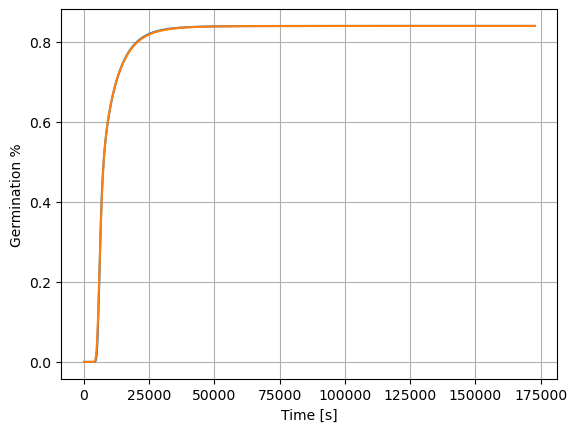

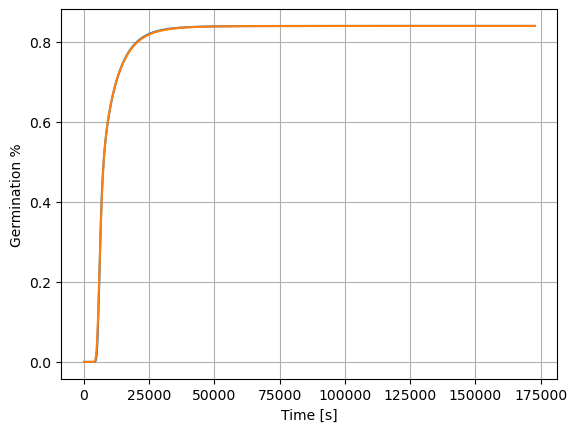

In [3]:
matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times, germination[1, :])
ax.plot(times, germination_2)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

## References